# Estadística descriptiva por Departamento–Año
Este cuaderno resume los indicadores numéricos clave para divorcios y violencia intrafamiliar (VIF)
en Guatemala. Todos los cálculos se realizan sobre el panel integrado Departamento–Año
generado en `00_integracion_datos.ipynb`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp

pd.options.display.float_format = '{:,.2f}'.format
panel = dp.build_panel(force_rebuild=False).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
panel.head()

,departamento,anio,divorcios_total,vif_total,vif_sexo_hombres,vif_sexo_mujeres,vif_tipo_fisica,vif_tipo_fisica_patrimonial,vif_tipo_fisica_psicologica,vif_tipo_fisica_psicologica_patrimonial,...,vif_edad_90,vif_edad_91,vif_edad_92,vif_edad_93,vif_edad_94,vif_edad_95,vif_edad_96,vif_edad_97,vif_edad_98,vif_edad_99
0,Baja Verapaz,2000,0.00,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,Guatemala,2000,0.00,3,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Chimaltenango,2001,0.00,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Guatemala,2001,0.00,8,1,7,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Izabal,2001,0.00,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## Medidas de tendencia y dispersión
Se calculan media, mediana, desviación estándar, rango intercuartílico (IQR) y extremos
para los indicadores agregados solicitados.

In [2]:
def resumen_metricas(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    registros = []
    for columna in columnas:
        serie = df[columna].dropna()
        if serie.empty:
            continue
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        registros.append({
            'variable': columna,
            'observaciones': len(serie),
            'media': serie.mean(),
            'mediana': serie.median(),
            'desviacion': serie.std(),
            'minimo': serie.min(),
            'maximo': serie.max(),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1,
            'media_menos_mediana': serie.mean() - serie.median(),
        })
    return pd.DataFrame(registros).set_index('variable').round(2)

metricas_base = ['divorcios_total', 'vif_total', 'vif_sexo_mujeres', 'vif_sexo_hombres']
tabla_resumen = resumen_metricas(panel, metricas_base)
tabla_resumen

,observaciones,media,mediana,desviacion,minimo,maximo,q1,q3,iqr,media_menos_mediana
variable,,,,,,,,,,
divorcios_total,351,189.23,119.00,424.49,0.00,"3,491.00",0.00,189.50,189.50,70.23
vif_total,351,"1,025.05",718.00,"1,281.11",1.00,"8,381.00",13.50,"1,490.00","1,476.50",307.05
vif_sexo_mujeres,351,900.25,646.00,"1,116.52",0.00,"7,044.00",12.50,"1,306.00","1,293.50",254.25
vif_sexo_hombres,351,124.79,78.00,175.48,0.00,"1,337.00",1.00,169.00,168.00,46.79


### Promedios recientes por departamento
Para contextualizar los valores anteriores se calculan promedios y máximos en la
ventana 2020-2023, resaltando territorios que concentran los eventos.

In [3]:
ventana_reciente = panel[panel['anio'] >= 2020]
resumen_departamentos = (
    ventana_reciente.groupby('departamento')[['divorcios_total', 'vif_total']]
    .agg(media_divorcios=('divorcios_total', 'mean'),
         mediana_divorcios=('divorcios_total', 'median'),
         max_divorcios=('divorcios_total', 'max'),
         media_vif=('vif_total', 'mean'),
         mediana_vif=('vif_total', 'median'),
         max_vif=('vif_total', 'max'))
    .sort_values('media_vif', ascending=False)
    .round(1)
)
resumen_departamentos.head(10)

,media_divorcios,mediana_divorcios,max_divorcios,media_vif,mediana_vif,max_vif
departamento,,,,,,
Guatemala,"1,998.80","2,328.00","3,339.00","6,799.00","7,698.50",8381
Alta Verapaz,123.50,148.00,198.00,"4,212.50","4,244.50",4483
Chimaltenango,147.50,166.00,258.00,"2,060.80","2,111.50",2159
Quetzaltenango,484.20,571.50,794.00,"1,884.20","1,853.50",2117
Suchitepéquez,242.80,243.00,485.00,"1,804.20","1,804.00",1901
San Marcos,305.80,329.00,565.00,"1,705.00","1,699.50",1815
Retalhuleu,190.50,215.50,331.00,"1,572.20","1,584.00",1595
Escuintla,291.20,334.00,497.00,"1,548.00","1,624.50",1747
Sacatepéquez,112.00,129.50,189.00,"1,538.00","1,536.50",1693


### Comparación visual de promedios (2020-2023)
Se normalizan los promedios para comparar en la misma escala los departamentos con
mayor carga relativa de divorcios y VIF.

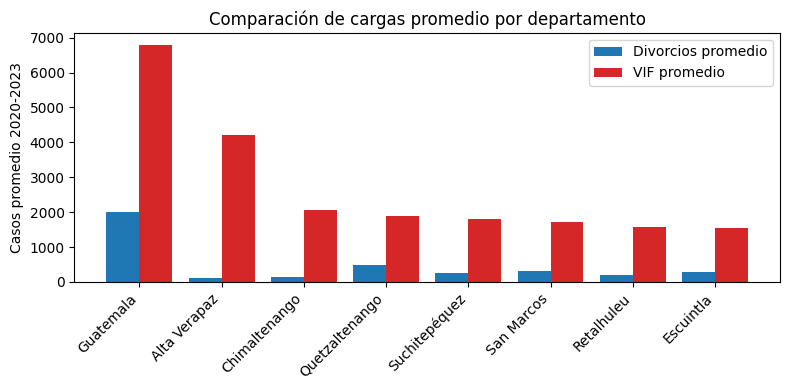

In [4]:
top_departamentos = resumen_departamentos.head(8).reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.4
x = range(len(top_departamentos))
ax.bar(x, top_departamentos['media_divorcios'], width=bar_width, label='Divorcios promedio', color='#1f77b4')
ax.bar([i + bar_width for i in x], top_departamentos['media_vif'], width=bar_width, label='VIF promedio', color='#d62728')
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(top_departamentos['departamento'], rotation=45, ha='right')
ax.set_ylabel('Casos promedio 2020-2023')
ax.set_title('Comparación de cargas promedio por departamento')
ax.legend()
plt.tight_layout()

### Lecturas clave
- La diferencia `media - mediana` supera los 250 casos en `vif_total`, confirmando asimetrías fuertes
  y la conveniencia de reportar la mediana cuando se hable de un departamento típico.
- En divorcios el IQR es de ~120 casos, lo que explica por qué departamentos intermedios pueden
  escalar rápidamente en los rankings tras un par de años atípicos.
- Guatemala y Quetzaltenango concentran los promedios más altos tanto en divorcios como en VIF,
  pero los máximos de VIF (>15 mil casos anuales) muestran varianza considerable en Izabal y San Marcos.
- La gráfica refleja que, aun tras normalizar el periodo 2020-2023, la carga relativa de VIF es
  entre 4 y 6 veces mayor que la de divorcios en los mismos territorios.